# Makemore v3 — Baby PyTorch port

This notebook ports the normalized-plus-batch-normalized experiment based on
Anderj Karpathy's makemore. It uses Baby PyTorch for
autograd, layers, initialization, loss, evaluation mode, and optimization, and
NumPy for data preparation and batching.

In [1]:
from pathlib import Path
import random

import matplotlib.pyplot as plt
import numpy as np

from baby_pytorch.loss import cross_entropy
from baby_pytorch.nn import (
    BatchNorm1d,
    Embedding,
    Linear,
    Module,
    Tanh,
    kaiming_normal_,
)
from baby_pytorch.optim import SGD
from baby_pytorch.tensor import Tensor

%matplotlib inline

SEED = 22334455
np.random.seed(SEED)

# Data preparation

In [2]:
data_path = Path("data/names.txt")
if not data_path.exists():
    data_path = Path("examples/data/names.txt")

names = data_path.read_text().splitlines()
random.seed(SEED)
random.shuffle(names)

alphabet = "." + "".join(sorted(set("".join(names))))
alphabet_len = len(alphabet)
char_to_idx = {character: index for index, character in enumerate(alphabet)}

print(names[:10])
print(f"{len(names):,} names")
print(alphabet)
print(f"alphabet length: {alphabet_len}")

['maitreya', 'nakari', 'kalessi', 'elex', 'jacinda', 'skylor', 'adalae', 'kenn', 'ephram', 'capri']
32,033 names
.abcdefghijklmnopqrstuvwxyz
alphabet length: 27


In [3]:
def create_data_sample(word, prefix_len):
    contexts, targets = [], []
    prefix = [char_to_idx["."]] * prefix_len
    for character in word + ".":
        contexts.append(prefix)
        index = char_to_idx[character]
        targets.append(index)
        prefix = prefix[1:] + [index]
    return contexts, targets


def index_to_word(indexes):
    return "".join(alphabet[index] for index in indexes)


def create_dataset(words, prefix_len):
    contexts, targets = [], []
    for word in words:
        word_contexts, word_targets = create_data_sample(word, prefix_len)
        contexts.extend(word_contexts)
        targets.extend(word_targets)
    return np.asarray(contexts, dtype=np.int64), np.asarray(targets, dtype=np.int64)


def print_dataset(contexts, targets):
    for context, target in zip(contexts, targets):
        print(f"{index_to_word(context)} --> {alphabet[target]}")

In [4]:
num_prefix_chars = 5
training_set_size = int(0.8 * len(names))
dev_set_size = int(0.1 * len(names))

training_set = names[:training_set_size]
dev_set = names[training_set_size:training_set_size + dev_set_size]
test_set = names[training_set_size + dev_set_size:]

train_data, train_labels = create_dataset(training_set, num_prefix_chars)
dev_data, dev_labels = create_dataset(dev_set, num_prefix_chars)
test_data, test_labels = create_dataset(test_set, num_prefix_chars)

print("--- TRAIN ---")
print_dataset(train_data[:10], train_labels[:10])
print("\n--- DEV ---")
print_dataset(dev_data[:10], dev_labels[:10])
print("\n--- TEST ---")
print_dataset(test_data[:10], test_labels[:10])
print("\nshapes:")
print("train:", train_data.shape, train_labels.shape)
print("dev:  ", dev_data.shape, dev_labels.shape)
print("test: ", test_data.shape, test_labels.shape)

--- TRAIN ---
..... --> m
....m --> a
...ma --> i
..mai --> t
.mait --> r
maitr --> e
aitre --> y
itrey --> a
treya --> .
..... --> n

--- DEV ---
..... --> z
....z --> v
...zv --> i
..zvi --> .
..... --> m
....m --> a
...ma --> n
..man --> u
.manu --> e
manue --> l

--- TEST ---
..... --> e
....e --> m
...em --> b
..emb --> y
.emby --> r
embyr --> .
..... --> c
....c --> r
...cr --> a
..cra --> w

shapes:
train: (182464, 5) (182464,)
dev:   (22861, 5) (22861,)
test:  (22821, 5) (22821,)


# Neural network

In [5]:
class Network(Module):
    def __init__(
        self,
        alphabet_len,
        num_prefix_chars,
        num_embedding_dims,
        hidden_layers,
        normalize=True,
        batch_norm=True,
    ):
        super().__init__()
        self.alphabet_len = alphabet_len
        self.num_prefix_chars = num_prefix_chars
        self.num_embedding_dims = num_embedding_dims
        self.hidden_layers = hidden_layers

        self.embedding = Embedding(alphabet_len, num_embedding_dims)
        self.layers = [self.embedding]

        fan_in = num_prefix_chars * num_embedding_dims
        linear = Linear(fan_in, hidden_layers[0], bias=not batch_norm)
        if normalize:
            kaiming_normal_(linear.weights, fan_in, "tanh")
        self.layers.append(linear)

        if batch_norm:
            self.layers.append(BatchNorm1d(hidden_layers[0]))

        self.layers.append(Tanh())
        
        fan_in = hidden_layers[0]
        for hidden_size in hidden_layers[1:]:
            self.layers.append(Linear(fan_in, hidden_size, bias=False))
            if batch_norm:
                self.layers.append(BatchNorm1d(hidden_size))
            self.layers.append(Tanh())
            fan_in = hidden_size

        self.layers.append(Linear(hidden_layers[-1], alphabet_len))
        if batch_norm:
            self.layers.append(BatchNorm1d(alphabet_len))

    def forward(self, contexts, training):
        embedded = self.embedding(contexts, training)
        output = embedded.reshape(
            contexts.shape[0],
            self.num_prefix_chars * self.num_embedding_dims,
        )
        for layer in self.layers[1:]:
            output = layer(output, training)
        return output

    def parameters(self):
        return [
            parameter
            for layer in self.layers
            for parameter in layer.parameters()
        ]

    def save_weights(self):
        return [layer.save_weights() for layer in self.layers]

    def load_weights(self, weights):
        if len(weights) != len(self.layers):
            raise ValueError(
                f"Expected weights for {len(self.layers)} layers, received {len(weights)}."
            )
        for layer, layer_weights in zip(self.layers, weights):
            layer.load_weights(layer_weights)

    def __repr__(self):
        return repr(self.layers)


num_layers = 4
hidden_layer_sizes = [100] * num_layers
num_embedding_dims = 5

# Keep only the source notebook's final experiment: normalization + BatchNorm.
model = Network(
    alphabet_len,
    num_prefix_chars,
    num_embedding_dims,
    hidden_layer_sizes,
    normalize=True,
    batch_norm=True,
)
print(model)
print(f"{sum(parameter.data.size for parameter in model.parameters()):,} parameters")

[Embedding: shape((27, 5)), Linear: weights: (25, 100) bias: None, BatchNorm1d: self.gamma.shape=(100,), self.beta.shape=(100,), Tanh, Linear: weights: (100, 100) bias: None, BatchNorm1d: self.gamma.shape=(100,), self.beta.shape=(100,), Tanh, Linear: weights: (100, 100) bias: None, BatchNorm1d: self.gamma.shape=(100,), self.beta.shape=(100,), Tanh, Linear: weights: (100, 100) bias: None, BatchNorm1d: self.gamma.shape=(100,), self.beta.shape=(100,), Tanh, Linear: weights: (100, 27) bias: (27,), BatchNorm1d: self.gamma.shape=(27,), self.beta.shape=(27,)]
36,216 parameters


# Training

In [6]:
def evaluate_loss(model, data, labels, batch_size=None):
    batch_size = len(data) if batch_size is None else batch_size
    total_loss = 0.0
    for start in range(0, len(data), batch_size):
        stop = min(start + batch_size, len(data))
        contexts = Tensor(data[start:stop], dtype=int)
        logits = model(contexts, training=False)
        loss = cross_entropy(logits, labels[start:stop])
        total_loss += float(loss.data) * (stop - start)
    return total_loss / len(data)


def train(model, num_epochs, lr, batch_size):
    optimizer = SGD(model.parameters(), lr=lr)
    rng = np.random.default_rng(SEED)
    initial_dev_loss = evaluate_loss(model, dev_data, dev_labels)
    best_dev_loss = initial_dev_loss
    best_epoch = -1
    best_config = {
        "best_loss": initial_dev_loss,
        "best_epoch": best_epoch,
        "num_embedding_dims": model.num_embedding_dims,
        "hidden_layer_size": model.hidden_layers,
        "weights": model.save_weights(),
    }
    diagnostics = {
        "ud_ratio": {},
        "saturation": {},
        "dead": {},
        "train_loss": [],
        "dev_loss": [],
    }

    print(f"initial dev loss: {initial_dev_loss:.4f}")
    for epoch in range(num_epochs):
        epoch_loss = 0.0
        num_batches = 0
        permutation = rng.permutation(len(train_data))

        for start in range(0, len(train_data), batch_size):
            indexes = permutation[start:start + batch_size]
            contexts = Tensor(train_data[indexes], dtype=int)
            targets = train_labels[indexes]

            optimizer.zero_grad()
            loss = cross_entropy(model(contexts), targets)
            loss.backward()
            optimizer.step()

            epoch_loss += float(loss.data)
            num_batches += 1

        epoch_loss /= num_batches
        dev_loss = evaluate_loss(model, dev_data, dev_labels)

        matrix_parameters = [
            parameter for parameter in model.parameters()
            if parameter.data.ndim == 2
        ]
        tanh_layers = [
            layer for layer in model.layers
            if isinstance(layer, Tanh)
        ]
        diagnostics["ud_ratio"][epoch] = [
            np.log10(
                optimizer.lr * np.mean(np.abs(parameter.grad))
                / (np.mean(np.abs(parameter.data)) + 1e-12)
                + 1e-12
            )
            for parameter in matrix_parameters
        ]
        diagnostics["saturation"][epoch] = [
            np.mean(np.abs(layer.out.data) > 0.99)
            for layer in tanh_layers
        ]
        diagnostics["dead"][epoch] = [
            np.mean(np.all(np.abs(layer.out.data) > 0.99, axis=0))
            for layer in tanh_layers
        ]
        diagnostics["train_loss"].append(epoch_loss)
        diagnostics["dev_loss"].append(dev_loss)

        print(f"epoch={epoch}: train_loss={epoch_loss:.4f}, dev_loss={dev_loss:.4f}")
        if dev_loss < best_dev_loss:
            best_dev_loss = dev_loss
            best_epoch = epoch
            best_config = {
                "best_loss": best_dev_loss,
                "best_epoch": best_epoch,
                "num_embedding_dims": model.num_embedding_dims,
                "hidden_layer_size": model.hidden_layers,
                "weights": model.save_weights(),
            }

    assert np.all(np.isfinite(diagnostics["train_loss"]))
    assert np.all(np.isfinite(diagnostics["dev_loss"]))
    assert best_dev_loss < initial_dev_loss
    return best_config, diagnostics


lr = 0.1
num_epochs = 30
batch_size = 64

print(
    f"Starting normalized + BatchNorm training with "
    f"{num_embedding_dims=} and {hidden_layer_sizes=}"
)
best_config, diagnostics = train(model, num_epochs, lr, batch_size)
print(
    f"best epoch={best_config['best_epoch']}, "
    f"best dev loss={best_config['best_loss']:.4f}"
)

Starting normalized + BatchNorm training with num_embedding_dims=5 and hidden_layer_sizes=[100, 100, 100, 100]
initial dev loss: 20.8777
epoch=0: train_loss=2.5657, dev_loss=2.4067
epoch=1: train_loss=2.3662, dev_loss=2.3197
epoch=2: train_loss=2.3095, dev_loss=2.2757
epoch=3: train_loss=2.2761, dev_loss=2.2503
epoch=4: train_loss=2.2542, dev_loss=2.2299
epoch=5: train_loss=2.2366, dev_loss=2.2179
epoch=6: train_loss=2.2229, dev_loss=2.2043
epoch=7: train_loss=2.2124, dev_loss=2.1955
epoch=8: train_loss=2.2044, dev_loss=2.1846
epoch=9: train_loss=2.1958, dev_loss=2.1826
epoch=10: train_loss=2.1882, dev_loss=2.1795
epoch=11: train_loss=2.1824, dev_loss=2.1674
epoch=12: train_loss=2.1767, dev_loss=2.1618
epoch=13: train_loss=2.1723, dev_loss=2.1587
epoch=14: train_loss=2.1686, dev_loss=2.1537
epoch=15: train_loss=2.1642, dev_loss=2.1516
epoch=16: train_loss=2.1598, dev_loss=2.1504
epoch=17: train_loss=2.1574, dev_loss=2.1488
epoch=18: train_loss=2.1525, dev_loss=2.1455
epoch=19: train_lo

In [7]:
model.load_weights(best_config["weights"])
final_losses = {
    "train": evaluate_loss(model, train_data, train_labels, batch_size=4096),
    "dev": evaluate_loss(model, dev_data, dev_labels, batch_size=4096),
    "test": evaluate_loss(model, test_data, test_labels, batch_size=4096),
}
for split, loss in final_losses.items():
    print(f"{split:>5} loss: {loss:.4f}")
assert np.all(np.isfinite(list(final_losses.values())))

train loss: 2.0744
  dev loss: 2.1177
 test loss: 2.1322


# Diagnostics

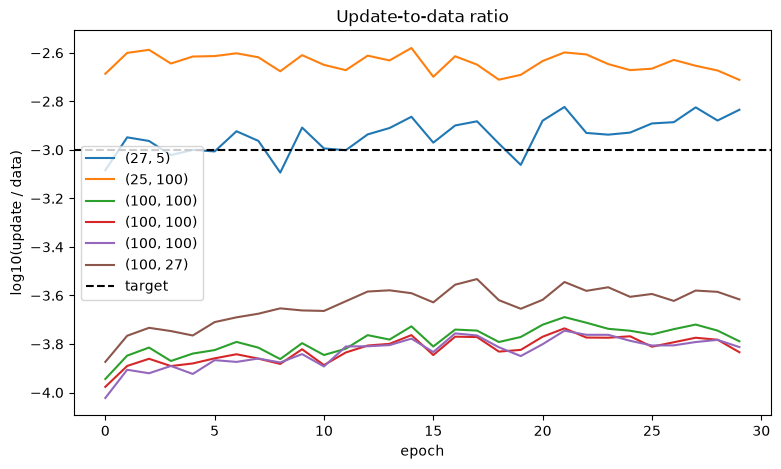

In [8]:
def plot_ud_ratio(model, ud_log):
    plt.figure(figsize=(9, 5))
    epochs = sorted(ud_log)
    shapes = [
        parameter.shape
        for parameter in model.parameters()
        if parameter.data.ndim == 2
    ]
    for index, shape in enumerate(shapes):
        plt.plot(epochs, [ud_log[epoch][index] for epoch in epochs], label=str(shape))
    plt.axhline(-3, color="black", linestyle="--", label="target")
    plt.xlabel("epoch")
    plt.ylabel("log10(update / data)")
    plt.title("Update-to-data ratio")
    plt.legend()
    plt.show()


plot_ud_ratio(model, diagnostics["ud_ratio"])

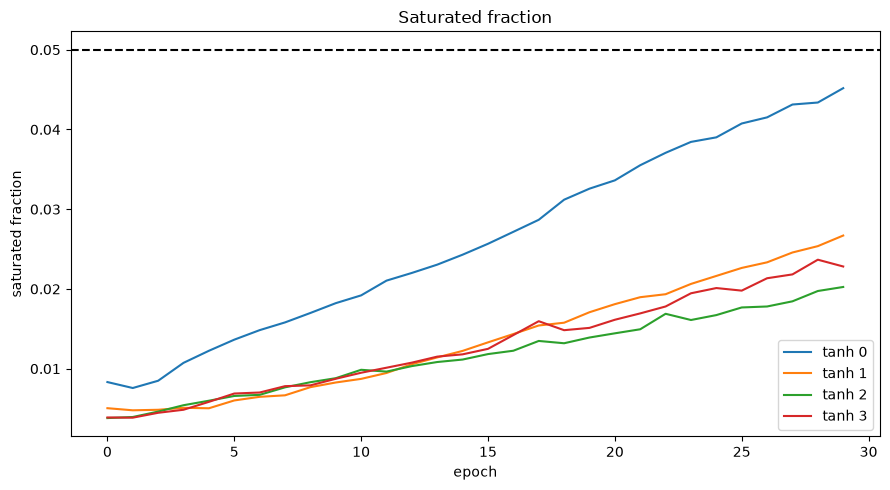

In [9]:
def plot_layer_metric(model, log, title, key, target=None):
    plt.figure(figsize=(9, 5))
    epochs = sorted(log)
    tanh_layers = [layer for layer in model.layers if isinstance(layer, Tanh)]
    for index in range(len(tanh_layers)):
        plt.plot(
            epochs,
            [log[epoch][index] for epoch in epochs],
            label=f"tanh {index}",
        )
    if target is not None:
        plt.axhline(target, color="black", linestyle="--")
    plt.xlabel("epoch")
    plt.ylabel(key)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_layer_metric(
    model,
    diagnostics["saturation"],
    "Saturated fraction",
    "saturated fraction",
    target=0.05,
)

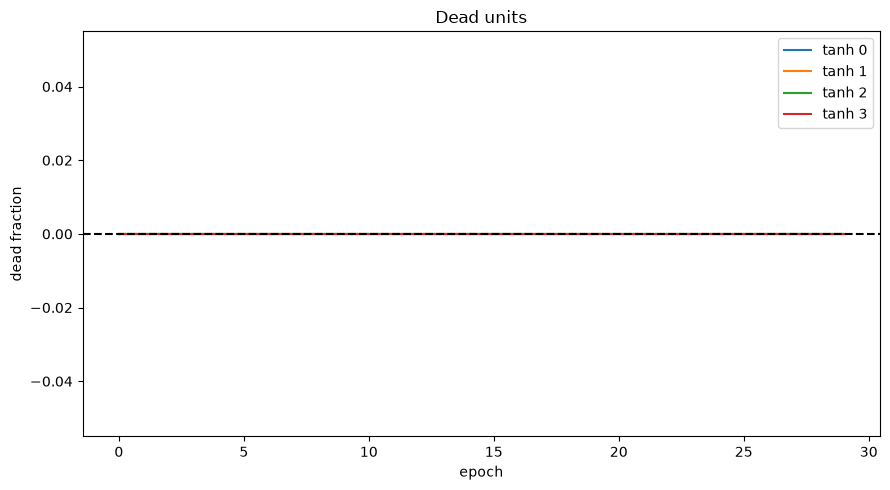

In [10]:
plot_layer_metric(
    model,
    diagnostics["dead"],
    "Dead units",
    "dead fraction",
    target=0.0,
)